# Core Signatures

### Marcos Costa Santos Carreira

### Oct-2023

## Imports

In [2]:
import numpy as np
import pandas as pd
import scipy as sc
import matplotlib.pyplot as plt

## Functions

In [3]:
def elem_signat_line(multiind, betas, dt=1):
    k = len(multiind)
    elem = 1
    if k > 0:
        for i in range(k):
            elem = elem * betas[multiind[i] - 1] * dt / (i + 1)
    return elem

In [4]:
elem_signat_line([2, 2, 2], [1, 2], 3)

36.0

In [5]:
def elem_signat_chen_2lines(multiind, betas_1, dt_1, betas_2, dt_2):
    k = len(multiind)
    elem = 0
    for j in range(k + 1):
        if j == 0:
            sign_1 = 1
            range_2 = multiind
            sign_2 = elem_signat_line(range_2, betas_2, dt_2)
        elif j == k:
            range_1 = multiind
            sign_1 = elem_signat_line(range_1, betas_1, dt_1)
            sign_2 = 1
        else:
            range_1 = multiind[:j]
            sign_1 = elem_signat_line(range_1, betas_1, dt_1)
            range_2 = multiind[j:]
            sign_2 = elem_signat_line(range_2, betas_2, dt_2)   
        elem = elem + sign_1 * sign_2
    return elem

In [6]:
elem_signat_chen_2lines([2, 2, 2], [1, 2], 3, [1, 3], 1)

121.5

In [7]:
def full_signat_line_level5(betas, dt=1):
    # Yes, this is ugly, but it works
    dim = len(betas)
    ans = [[1]]
    new_row = [elem_signat_line([a], betas, dt) for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[elem_signat_line([a, b], betas, dt) for b in range (1, dim + 1)]
               for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[elem_signat_line([a, b, c], betas, dt) for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[elem_signat_line([a, b, c, d], betas, dt) for d in range (1, dim + 1)]
                 for c in range (1, dim + 1)] for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[[elem_signat_line([a, b, c, d, e], betas, dt) for e in range (1, dim + 1)]
                  for d in range (1, dim + 1)] for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    return ans

In [8]:
def get_elem(multiind, signat):
    ans = signat[len(multiind)]
    for m in multiind:
        ans = ans[m - 1]
    return ans

In [9]:
test_sign_1 = [[1], [2, 3], [[4, 5], [6, 7]], [[[8, 9], [10, 11]], [[12, 13], [14, 15]]]]

In [10]:
get_elem([2], test_sign_1)

3

In [11]:
get_elem([1, 2], test_sign_1)

5

In [12]:
get_elem([2, 2, 2], test_sign_1)

15

In [13]:
def get_core_level5(signat):
    ans1 = signat[1]
    ans2 = [get_elem([1, 2], signat)]
    ans3 = [get_elem([1, 1, 2], signat), get_elem([1, 2, 2], signat)]
    ans4 = [get_elem([1, 1, 1, 2], signat), get_elem([1, 1, 2, 2], signat),
             get_elem([1, 2, 2, 2], signat)]
    ans5 = [get_elem([1, 1, 1, 1, 2], signat), get_elem([1, 1, 1, 2, 2], signat),
             get_elem([1, 1, 2, 1, 2], signat), get_elem([1, 1, 2, 2, 2], signat),
             get_elem([1, 2, 1, 2, 2], signat), get_elem([1, 2, 2, 2, 2], signat)]
    return {1: ans1, 2: ans2, 3: ans3, 4: ans4, 5: ans5}

In [64]:
def get_flat_core_level5(signat):
    ans1 = signat[1]
    ans2 = [get_elem([1, 2], signat)]
    ans3 = [get_elem([1, 1, 2], signat), get_elem([1, 2, 2], signat)]
    ans4 = [get_elem([1, 1, 1, 2], signat), get_elem([1, 1, 2, 2], signat),
             get_elem([1, 2, 2, 2], signat)]
    ans5 = [get_elem([1, 1, 1, 1, 2], signat), get_elem([1, 1, 1, 2, 2], signat),
             get_elem([1, 1, 2, 1, 2], signat), get_elem([1, 1, 2, 2, 2], signat),
             get_elem([1, 2, 1, 2, 2], signat), get_elem([1, 2, 2, 2, 2], signat)]
    return ans1 + ans2 + ans3 + ans4 + ans5

In [14]:
def elem_signat_chen_2signats(multiind, signat_1, signat_2):
    k = len(multiind)
    elem = 0
    for j in range(k + 1):
        if j == 0:
            range_1 = []
            sign_1 = 1
            range_2 = multiind
            sign_2 = get_elem(range_2, signat_2)
        elif j == k:
            range_1 = multiind
            sign_1 = get_elem(range_1, signat_1)
            range_2 = []
            sign_2 = 1
        else:
            range_1 = multiind[:j]
            sign_1 = get_elem(range_1, signat_1)
            range_2 = multiind[j:]
            sign_2 = get_elem(range_2, signat_2)
        elem = elem + sign_1 * sign_2
    return elem

In [15]:
sigr1 = full_signat_line_level5([1, 2], 3)

In [16]:
sigr2 = full_signat_line_level5([1, 3], 1)

In [17]:
elem_signat_chen_2signats([1, 2], sigr1, sigr2)

19.5

In [18]:
def chain_chen_level5(signat_1, signat_2):
    # Yes, this is ugly, but it works
    dim = len(signat_1[1])
    ans = [[1]]
    new_row = [elem_signat_chen_2signats([a], signat_1, signat_2) for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[elem_signat_chen_2signats([a, b], signat_1, signat_2) for b in range (1, dim + 1)]
               for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[elem_signat_chen_2signats([a, b, c], signat_1, signat_2) for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[elem_signat_chen_2signats([a, b, c, d], signat_1, signat_2) for d in range (1, dim + 1)]
                 for c in range (1, dim + 1)] for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[[elem_signat_chen_2signats([a, b, c, d, e], signat_1, signat_2) for e in range (1, dim + 1)]
                  for d in range (1, dim + 1)] for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    return ans

In [19]:
sigr12 = chain_chen_level5(sigr1, sigr2)

In [20]:
sigr12

[[1],
 [4.0, 9.0],
 [[8.0, 19.5], [16.5, 40.5]],
 [[[10.666666666666668, 27.5], [23.0, 60.0]], [[21.5, 55.5], [46.5, 121.5]]],
 [[[[10.666666666666666, 28.625], [24.125, 65.625]],
   [[21.875, 58.875], [49.875, 136.125]]],
  [[[21.375, 57.375], [48.375, 131.625]],
   [[43.875, 118.125], [100.125, 273.375]]]],
 [[[[[8.533333333333333, 23.575], [20.2, 56.550000000000004]],
    [[17.95, 49.800000000000004], [43.050000000000004, 121.05]]],
   [[[17.2, 47.550000000000004], [40.800000000000004, 114.3]],
    [[36.3, 100.8], [87.3, 245.70000000000002]]]],
  [[[[17.075, 47.175000000000004], [40.425000000000004, 113.175]],
    [[35.925, 99.675], [86.175, 242.32500000000002]]],
   [[[34.425, 95.175], [81.675, 228.82500000000002]],
    [[72.675, 201.82500000000002], [174.82500000000002, 492.075]]]]]]

In [21]:
def full_signat_ts_level5(beta, dt):
    # Yes, this is ugly, but it works
    betas = [1, beta]
    dim = 2
    ans = [[1]]
    new_row = [elem_signat_line([a], betas, dt) for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[elem_signat_line([a, b], betas, dt) for b in range (1, dim + 1)]
               for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[elem_signat_line([a, b, c], betas, dt) for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[elem_signat_line([a, b, c, d], betas, dt) for d in range (1, dim + 1)]
                 for c in range (1, dim + 1)] for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    new_row = [[[[[elem_signat_line([a, b, c, d, e], betas, dt) for e in range (1, dim + 1)]
                  for d in range (1, dim + 1)] for c in range (1, dim + 1)]
                for b in range (1, dim + 1)] for a in range (1, dim + 1)]
    ans = ans + [new_row]
    return ans

In [22]:
full_signat_ts_level5(2, 3)

[[1],
 [3.0, 6.0],
 [[4.5, 9.0], [9.0, 18.0]],
 [[[4.5, 9.0], [9.0, 18.0]], [[9.0, 18.0], [18.0, 36.0]]],
 [[[[3.375, 6.75], [6.75, 13.5]], [[6.75, 13.5], [13.5, 27.0]]],
  [[[6.75, 13.5], [13.5, 27.0]], [[13.5, 27.0], [27.0, 54.0]]]],
 [[[[[2.025, 4.05], [4.05, 8.1]], [[4.05, 8.1], [8.1, 16.2]]],
   [[[4.05, 8.1], [8.1, 16.2]], [[8.1, 16.2], [16.2, 32.4]]]],
  [[[[4.05, 8.1], [8.1, 16.2]], [[8.1, 16.2], [16.2, 32.4]]],
   [[[8.1, 16.2], [16.2, 32.4]], [[16.2, 32.4], [32.4, 64.8]]]]]]

In [23]:
def chain_chen_ts(betas, dts):
    signat_5 = full_signat_ts_level5(betas[0], dts[0])
    if len(betas) > 1:
        for j in range(1, len(betas)):
            new_signat_5 = full_signat_ts_level5(betas[j], dts[j])
            signat_5 = chain_chen_level5(signat_5, new_signat_5)
    return signat_5

In [24]:
chain_chen_ts([2, 3], [3, 1])

[[1],
 [4.0, 9.0],
 [[8.0, 19.5], [16.5, 40.5]],
 [[[10.666666666666668, 27.5], [23.0, 60.0]], [[21.5, 55.5], [46.5, 121.5]]],
 [[[[10.666666666666666, 28.625], [24.125, 65.625]],
   [[21.875, 58.875], [49.875, 136.125]]],
  [[[21.375, 57.375], [48.375, 131.625]],
   [[43.875, 118.125], [100.125, 273.375]]]],
 [[[[[8.533333333333333, 23.575], [20.2, 56.550000000000004]],
    [[17.95, 49.800000000000004], [43.050000000000004, 121.05]]],
   [[[17.2, 47.550000000000004], [40.800000000000004, 114.3]],
    [[36.3, 100.8], [87.3, 245.70000000000002]]]],
  [[[[17.075, 47.175000000000004], [40.425000000000004, 113.175]],
    [[35.925, 99.675], [86.175, 242.32500000000002]]],
   [[[34.425, 95.175], [81.675, 228.82500000000002]],
    [[72.675, 201.82500000000002], [174.82500000000002, 492.075]]]]]]

In [25]:
def ir_curve_to_betas(maturities, points):
    sqrt_mats = np.sqrt(maturities)
    dts = np.diff(sqrt_mats)
    betas = np.diff(points) / dts
    return {'r0': points[0], 'betas': betas, 'dts': dts}

## Data

In [26]:
df_SETA = pd.read_csv('SETA.csv', index_col=0)

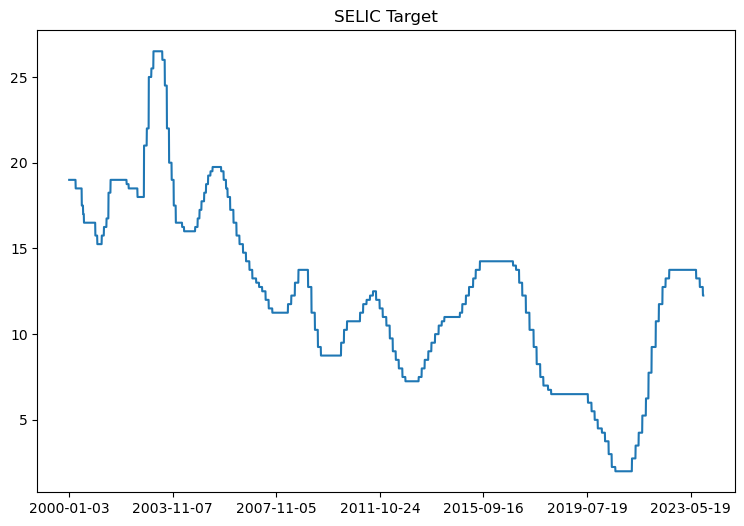

In [31]:
df_SETA['PX_LAST'].plot(figsize=(9, 6));
plt.title("SELIC Target");

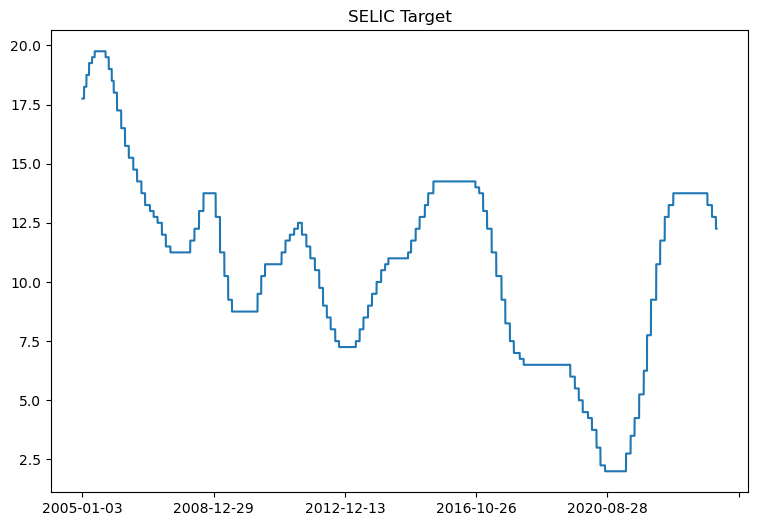

In [195]:
df_SETA['PX_LAST'].loc['2005':].plot(figsize=(9, 6));
plt.title("SELIC Target");

In [36]:
SOFR_mats_10 = ['A', 'B', 'C',
                'F', 'I', '1',
                '1F',
                '2', '3', '4', '5',
                '6', '7', '8', '9', '10']

In [37]:
sofr_yrs_10 = [1/12, 2/12, 3/12,
               6/12, 9/12, 1,
               3/2,
               2, 3, 4, 5,
               6, 7, 8, 9, 10]

In [38]:
sofr_sqrt_yrs_10 = np.sqrt(sofr_yrs_10)

In [46]:
sofr_dict_sqrt_mats_10 = dict(zip(SOFR_mats_10, sofr_sqrt_yrs_10))

In [47]:
sofr_dict_sqrt_mats_10

{'A': 0.28867513459481287,
 'B': 0.408248290463863,
 'C': 0.5,
 'F': 0.7071067811865476,
 'I': 0.8660254037844386,
 '1': 1.0,
 '1F': 1.224744871391589,
 '2': 1.4142135623730951,
 '3': 1.7320508075688772,
 '4': 2.0,
 '5': 2.23606797749979,
 '6': 2.449489742783178,
 '7': 2.6457513110645907,
 '8': 2.8284271247461903,
 '9': 3.0,
 '10': 3.1622776601683795}

In [135]:
df_SOFR = pd.read_csv('df_all_SOFR_10.csv', index_col=0)

In [103]:
df_Swpt = pd.read_csv('df_all_Swpt_10.csv', index_col=0)

In [136]:
SOFR_dates = sorted(list(set(df_SOFR.index.values)))

In [44]:
def get_sofr_str_mats(dict_mats, codes):
    return [dict_mats[str(m)] for m in list(codes)]

In [59]:
def betas_sofr_10(dict_mats, date):
    mats = get_sofr_str_mats(dict_mats, (df_SOFR.loc[date])['MATURITY'].values)
    rates = (df_SOFR.loc[date])['PX_LAST'].values
    return ir_curve_to_betas(mats, rates)

In [56]:
def plot_sofr_10(dict_mats, date, xlabel, ylabel):
    plt.rcParams['figure.figsize'] = [8, 5]
    plt.plot(
        get_sofr_str_mats(dict_mats, (df_SOFR.loc[date])['MATURITY'].values),
        (df_SOFR.loc[date])['PX_LAST'].values,
        marker='x');
    plt.title(date);
    plt.xlabel(xlabel);
    plt.ylabel(ylabel);

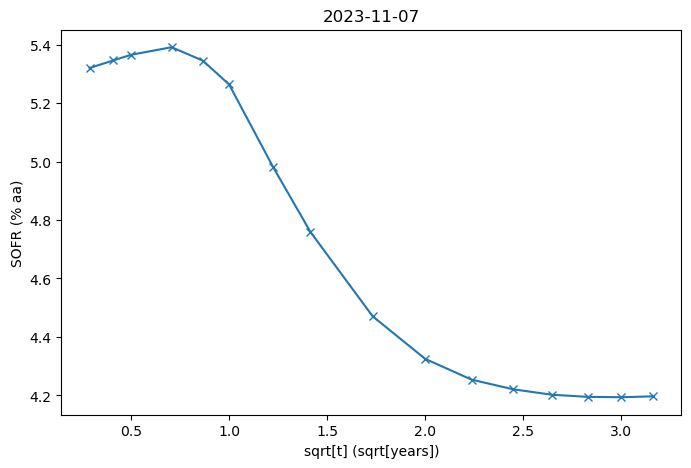

In [57]:
plot_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07', 'sqrt[t] (sqrt[years])', 'SOFR (% aa)')

In [61]:
betas_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07')

{'r0': 5.3197,
 'betas': array([ 0.25280809,  0.28607612,  0.19358749, -0.51165752, -1.17443381,
        -2.65087093, -2.67797003, -2.27876621, -1.48258272, -0.87384986,
        -0.47464861, -0.30085223, -0.13220741, -0.02387681,  0.06489489]),
 'dts': array([0.10165814, 0.06816368, 0.13378963, 0.08970844, 0.06939514,
        0.10668192, 0.0825252 , 0.1268669 , 0.09813955, 0.08113522,
        0.0697358 , 0.06149198, 0.05521627, 0.05025798, 0.0462286 ])}

In [63]:
temp = betas_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07')
get_core_level5(chain_chen_ts(temp['betas'], temp['dts']))

{1: [1.2409944441271517, -1.1227],
 2: [-0.772355864387711],
 3: [-0.27215595875371645, 0.38747499891664816],
 4: [-0.06721146484981307, 0.11635895149191526, -0.1395083711942128],
 5: [-0.013065145100108545,
  0.024075434072396235,
  0.01908882535033977,
  -0.038702082924086174,
  -0.01551246102211503,
  0.03874318493067887]}

In [65]:
temp = betas_sofr_10(sofr_dict_sqrt_mats_10, '2023-11-07')
get_flat_core_level5(chain_chen_ts(temp['betas'], temp['dts']))

[1.2409944441271517,
 -1.1227,
 -0.772355864387711,
 -0.27215595875371645,
 0.38747499891664816,
 -0.06721146484981307,
 0.11635895149191526,
 -0.1395083711942128,
 -0.013065145100108545,
 0.024075434072396235,
 0.01908882535033977,
 -0.038702082924086174,
 -0.01551246102211503,
 0.03874318493067887]

In [137]:
SOFR_cores_dict = {}
for d in SOFR_dates:
    betas = betas_sofr_10(sofr_dict_sqrt_mats_10, d)
    new_row = get_flat_core_level5(chain_chen_ts(betas['betas'], betas['dts']))
    SOFR_cores_dict[d] = new_row
SOFR_cores_df = pd.DataFrame(SOFR_cores_dict).transpose()
SOFR_cores_df.columns = ['1', '2', '12', '112', '122', '1112', '1122', '1222', '11112', '11122', '11212', '11222', '12122', '12222']

In [116]:
list(SOFR_cores_dict.keys())[-1]

'2023-11-07'

In [138]:
SOFR_cores_df

,1,2,12,112,122,1112,1122,1222,11112,11122,11212,11222,12122,12222
2007-01-31,1.240994,-0.0999,-0.052533,0.001225,0.006196,0.007389,0.002406,-0.000232,0.003215,0.000674,-0.001017,-0.000058,-0.000093,0.000010
2007-02-01,1.240994,-0.0806,-0.056266,-0.006555,0.005026,0.003496,0.001864,-0.000200,0.001980,0.000461,-0.000584,-0.000063,-0.000011,0.000007
2007-02-02,1.240994,-0.1081,-0.064318,-0.005578,0.006851,0.004737,0.002411,-0.000314,0.002437,0.000590,-0.000761,-0.000091,-0.000040,0.000013
2007-02-05,1.240994,-0.1361,-0.079232,-0.010113,0.008913,0.003830,0.002968,-0.000483,0.002322,0.000689,-0.000777,-0.000139,-0.000045,0.000022
2007-02-06,1.240994,-0.1747,-0.102311,-0.017234,0.012901,0.002343,0.004109,-0.000859,0.002089,0.000906,-0.000836,-0.000244,-0.000065,0.000047
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-11-01,1.240994,-0.9435,-0.641037,-0.213295,0.285253,-0.048121,0.084784,-0.089472,-0.008217,0.017055,0.010628,-0.024993,-0.007789,0.021585
2023-11-02,1.240994,-1.0139,-0.730071,-0.262157,0.341446,-0.065617,0.105428,-0.114516,-0.012910,0.022187,0.017173,-0.032952,-0.011549,0.029617
2023-11-03,1.240994,-1.1002,-0.721306,-0.240538,0.357195,-0.055502,0.103259,-0.125914,-0.009902,0.020537,0.014852,-0.033701,-0.013231,0.034198
2023-11-06,1.240994,-1.0392,-0.708372,-0.244088,0.334277,-0.058345,0.099720,-0.112496,-0.010860,0.020375,0.014963,-0.031191,-0.011584,0.029163


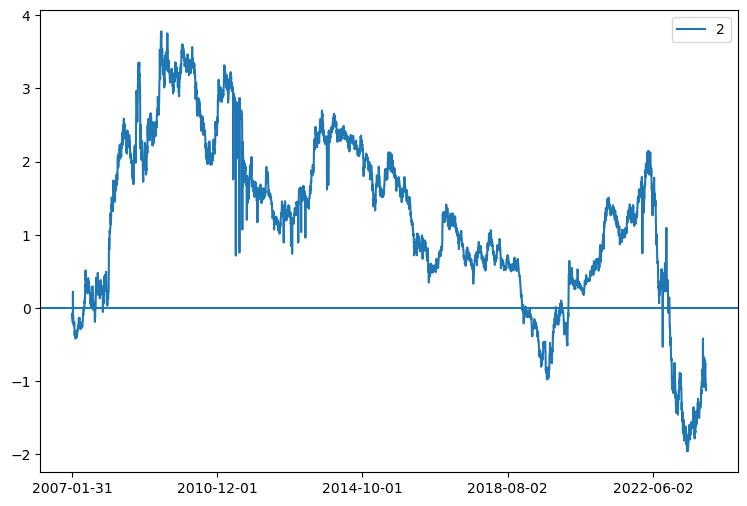

In [139]:
SOFR_cores_df[['2']].plot(figsize=(9, 6));
plt.axhline();

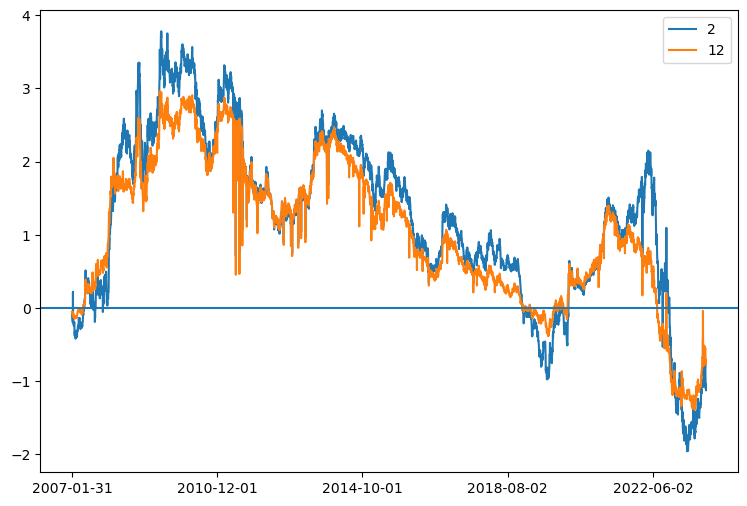

In [140]:
SOFR_cores_df[['2', '12']].plot(figsize=(9, 6));
plt.axhline();

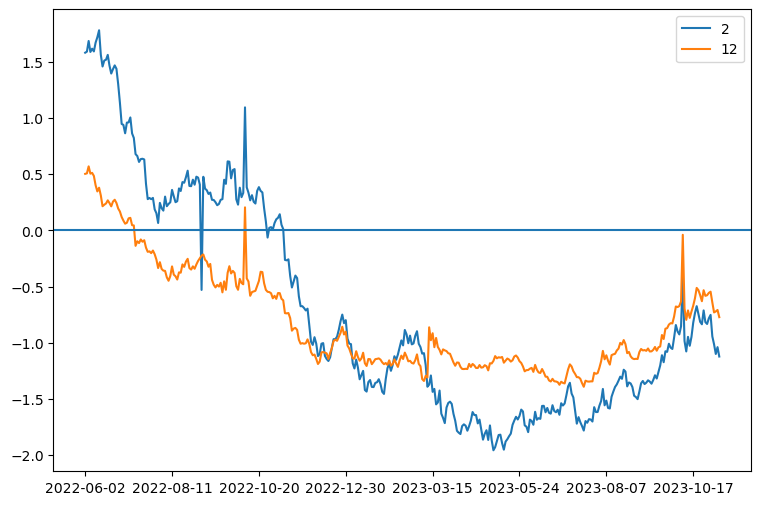

In [141]:
SOFR_cores_df[['2', '12']].loc['2022-06-02':].plot(figsize=(9, 6));
plt.axhline();

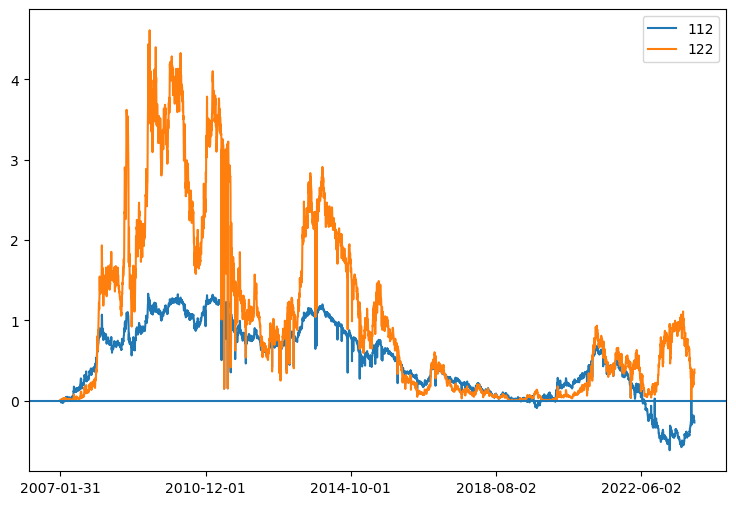

In [143]:
SOFR_cores_df[['112', '122']].plot(figsize=(9, 6));
plt.axhline();

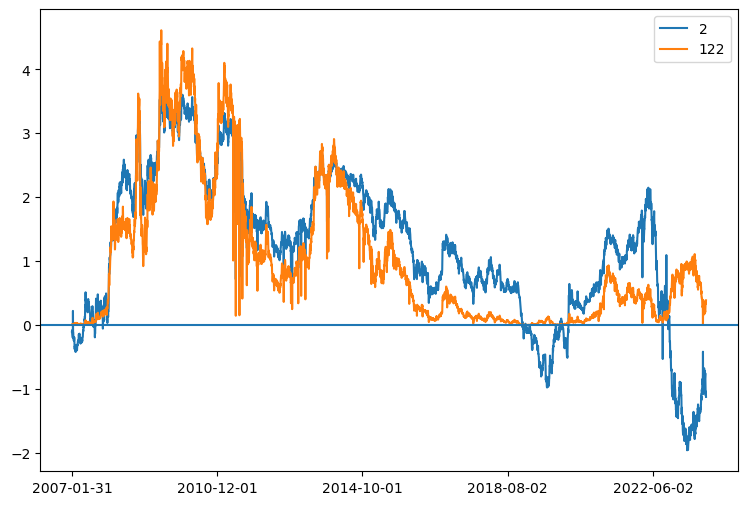

In [142]:
SOFR_cores_df[['2', '122']].plot(figsize=(9, 6));
plt.axhline();

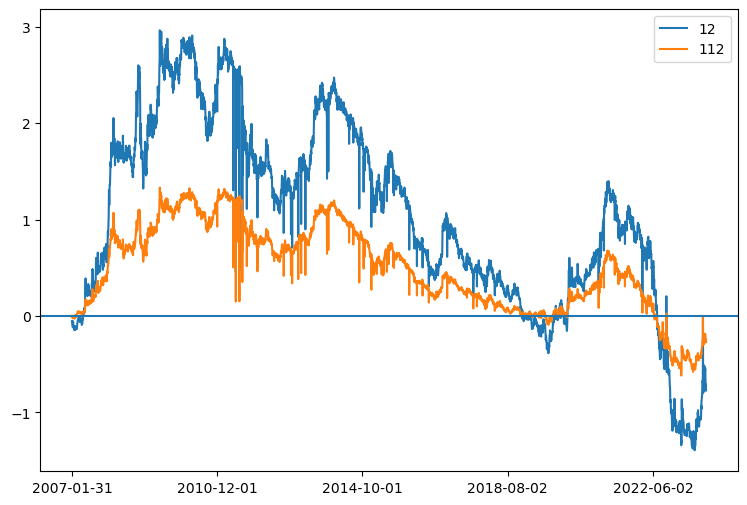

In [150]:
SOFR_cores_df[['12', '112']].plot(figsize=(9, 6));
plt.axhline();

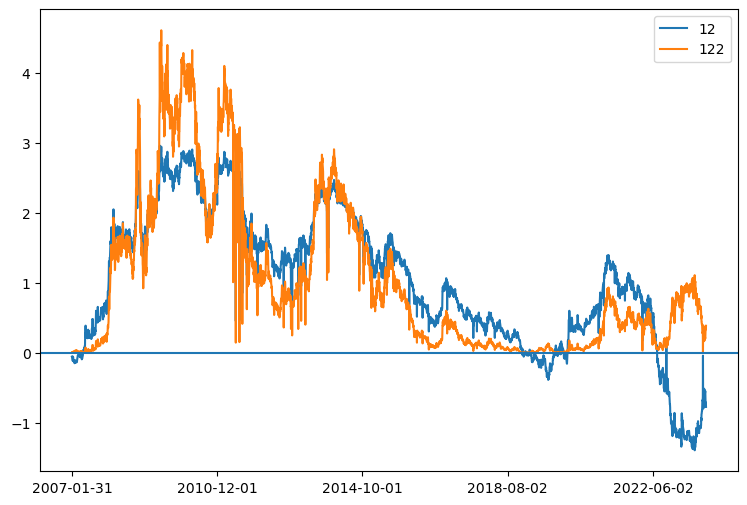

In [149]:
SOFR_cores_df[['12', '122']].plot(figsize=(9, 6));
plt.axhline();

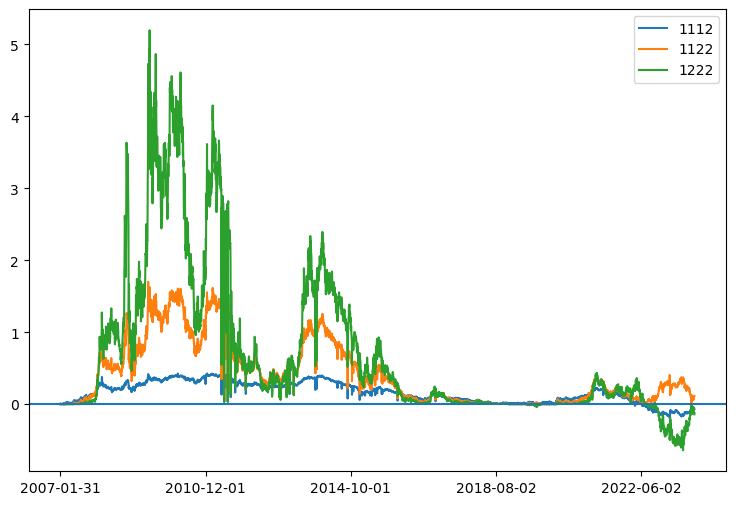

In [144]:
SOFR_cores_df[['1112', '1122', '1222']].plot(figsize=(9, 6));
plt.axhline();

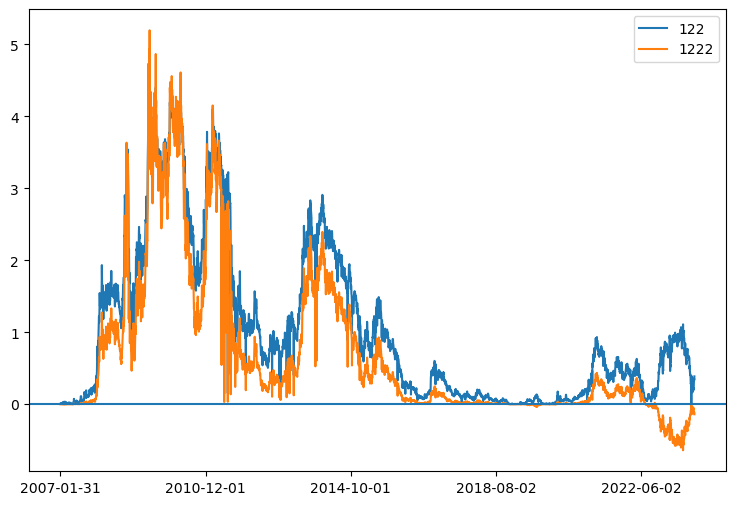

In [151]:
SOFR_cores_df[['122', '1222']].plot(figsize=(9, 6));
plt.axhline();

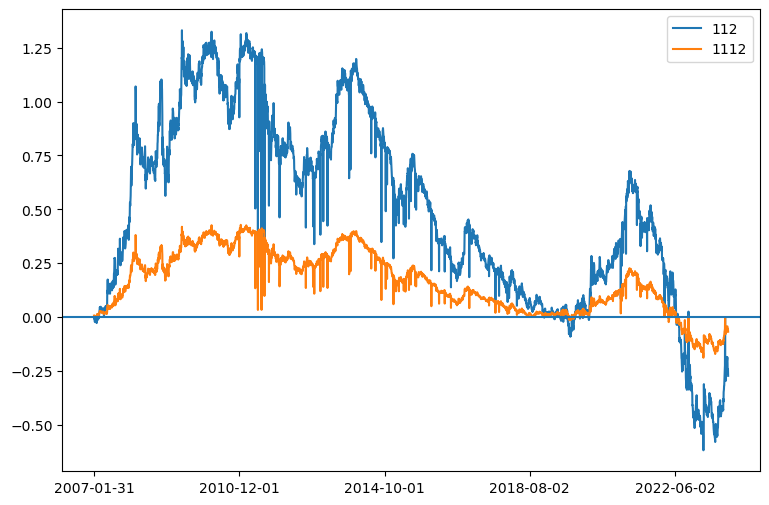

In [147]:
SOFR_cores_df[['112', '1112']].plot(figsize=(9, 6));
plt.axhline();

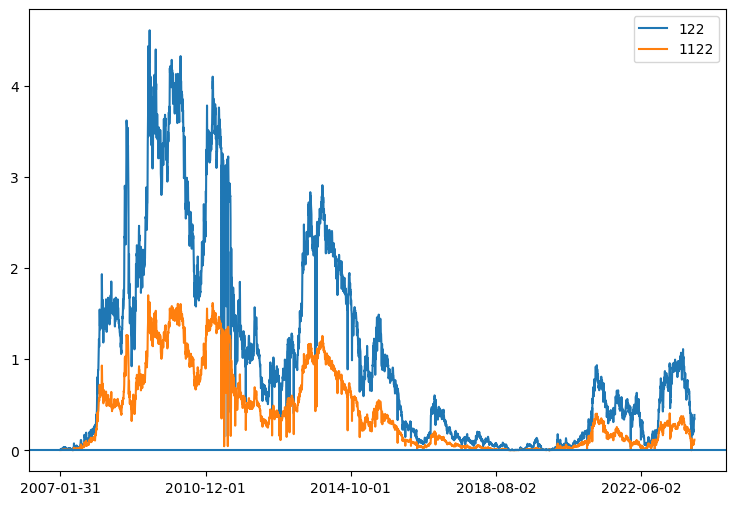

In [148]:
SOFR_cores_df[['122', '1122']].plot(figsize=(9, 6));
plt.axhline();

In [174]:
df_DI1 = pd.read_csv('df_all_DI1.csv', index_col=0).dropna(subset=['PX_SETTLE'])

In [175]:
df_DI1

,MATURITY,PX_SETTLE,FUT_BUS_DAYS_VAL,VOLUME,RT_OPEN_INTEREST,CONTRACT,EXCH_YEST_ADJ_ALT_SETT_RATE
Date,,,,,,,
2000-01-03,0.083333,19.105,21.0,9697.0,97996.0,ODG00,NaN
2000-01-04,0.079365,19.221,20.0,49167.0,101220.0,ODG00,NaN
2000-01-05,0.075397,19.203,19.0,13235.0,131594.0,ODG00,NaN
2000-01-06,0.071429,19.138,18.0,8060.0,136199.0,ODG00,NaN
2000-01-07,0.067460,19.071,17.0,5960.0,133223.0,ODG00,NaN
...,...,...,...,...,...,...,...
2023-10-31,14.126984,11.892,3560.0,NaN,3200.0,ODF38,11.933
2023-11-01,14.123016,11.715,3559.0,NaN,3200.0,ODF38,11.892
2023-11-03,14.119048,11.505,3558.0,NaN,3200.0,ODF38,11.715


In [177]:
DI1_dates = sorted(list(set(df_DI1.index.values)))

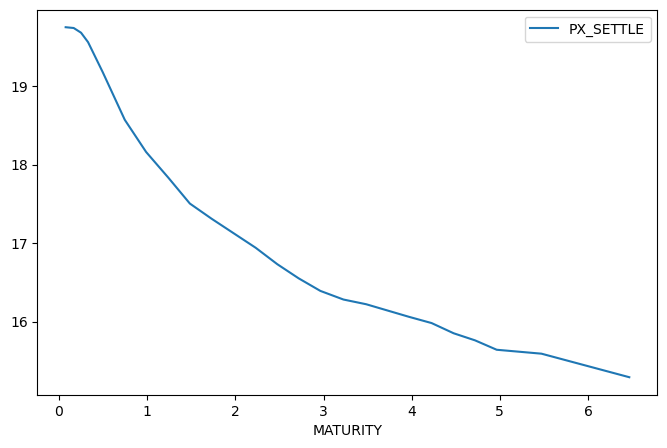

In [203]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2005-07-05'].set_index('MATURITY').plot();

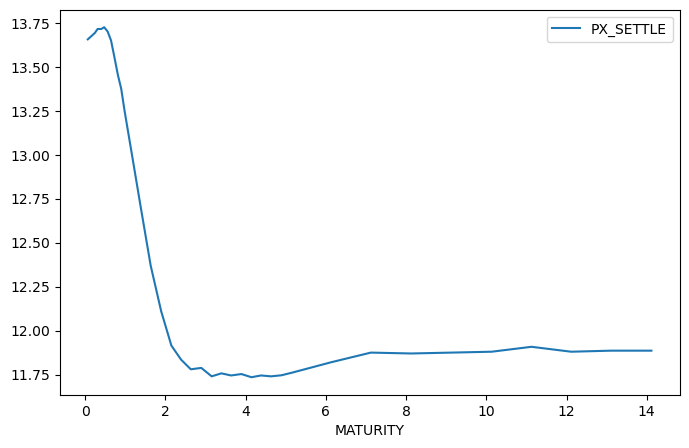

In [209]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2022-11-07'].set_index('MATURITY').plot();

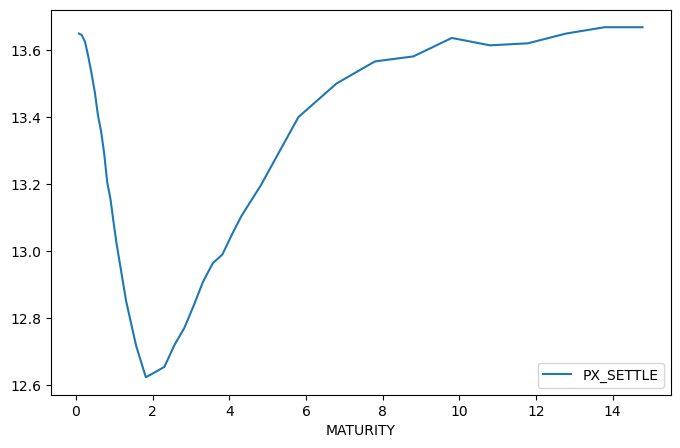

In [208]:
df_DI1[['MATURITY', 'PX_SETTLE']].loc['2023-03-07'].set_index('MATURITY').plot();

In [167]:
def betas_DI1(date):
    mats = np.sqrt(df_DI1.loc[date]['MATURITY'].values)
    rates = df_DI1.loc[date]['PX_SETTLE'].values
    return ir_curve_to_betas(mats, rates)

In [168]:
betas_DI1('2023-11-07')

{'r0': 12.154,
 'betas': array([-1.32570936, -1.59286549, -3.42067023, -2.85376943, -3.46237502,
        -4.00869153, -3.25775969, -3.22906804, -3.02204337, -3.29648657,
        -2.56369093, -1.38581709, -1.579597  , -0.37451227, -0.9485262 ,
         1.19493519,  1.22292451,  1.76478417,  0.77056009,  2.6545545 ,
         2.17578806,  1.92869907,  2.54409668,  2.23406903,  2.25275801,
         1.8286157 ,  1.43939405,  1.54492242,  1.47952028,  0.42041187,
         1.10738204,  0.72421176,  1.30967939, -0.86216956,  0.50454068,
         0.        ]),
 'dts': array([0.10937541, 0.07659153, 0.05028254, 0.04380172, 0.04101231,
        0.03417574, 0.02916114, 0.03034931, 0.02647215, 0.0233582 ,
        0.06241002, 0.05051172, 0.0443151 , 0.04272223, 0.03795362,
        0.03263775, 0.03025534, 0.030032  , 0.0272529 , 0.02448622,
        0.02435899, 0.02385027, 0.02201174, 0.02103785, 0.01953161,
        0.01968702, 0.01806316, 0.06796458, 0.06083053, 0.05470826,
        0.04966669, 0.04556

In [178]:
temp = betas_DI1('2023-11-07')
get_flat_core_level5(chain_chen_ts(temp['betas'], temp['dts']))

[1.428524676258008,
 -0.6760000000000002,
 0.3219291150711579,
 0.3123422604810929,
 0.1722889669792172,
 0.12671457068676736,
 0.10138513544332804,
 0.02697714946560902,
 0.03553458069811009,
 0.03634685513368645,
 -0.016693476322036587,
 0.022210913718802194,
 -0.056601214020872016,
 0.006852218182327762]

In [179]:
DI1_cores_dict = {}
for d in DI1_dates:
    betas = betas_DI1(d)
    new_row = get_flat_core_level5(chain_chen_ts(betas['betas'], betas['dts']))
    DI1_cores_dict[d] = new_row
DI1_cores_df = pd.DataFrame(DI1_cores_dict).transpose()
DI1_cores_df.columns = ['1', '2', '12', '112', '122', '1112', '1122', '1222', '11112', '11122', '11212', '11222', '12122', '12222']

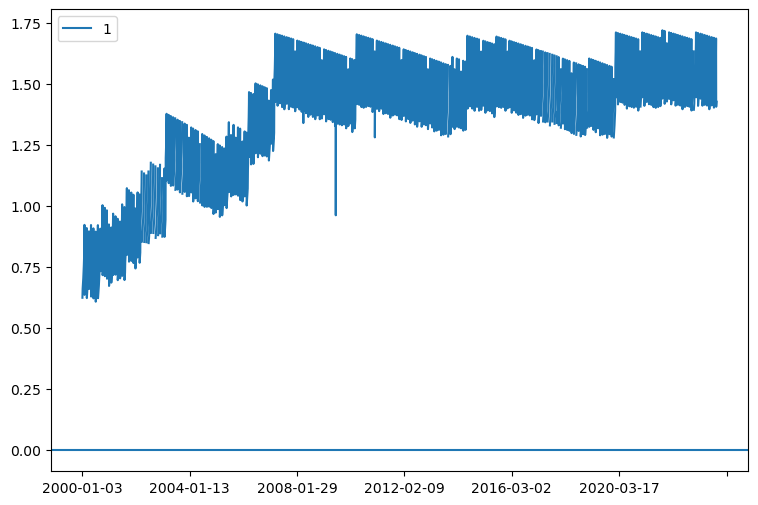

In [184]:
DI1_cores_df[['1']].plot(figsize=(9, 6));
plt.axhline();

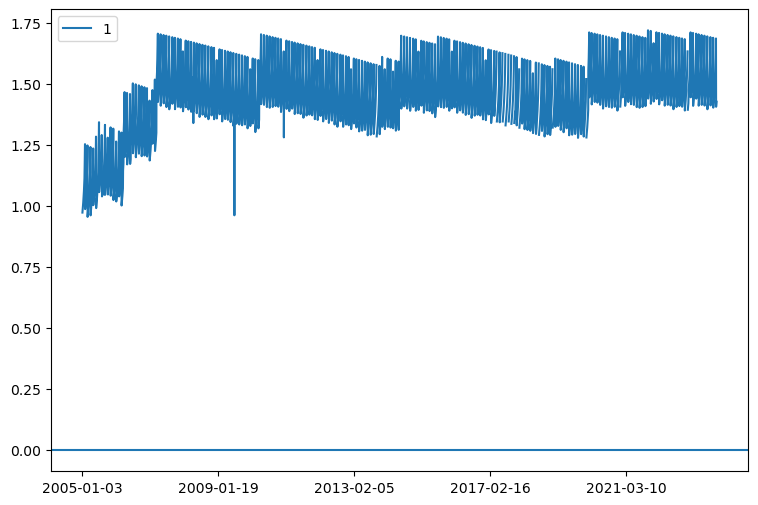

In [210]:
DI1_cores_df[['1']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

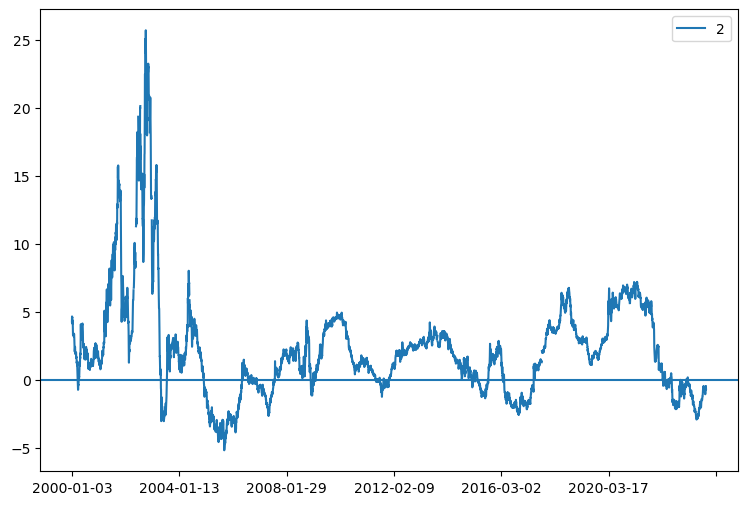

In [183]:
DI1_cores_df[['2']].plot(figsize=(9, 6));
plt.axhline();

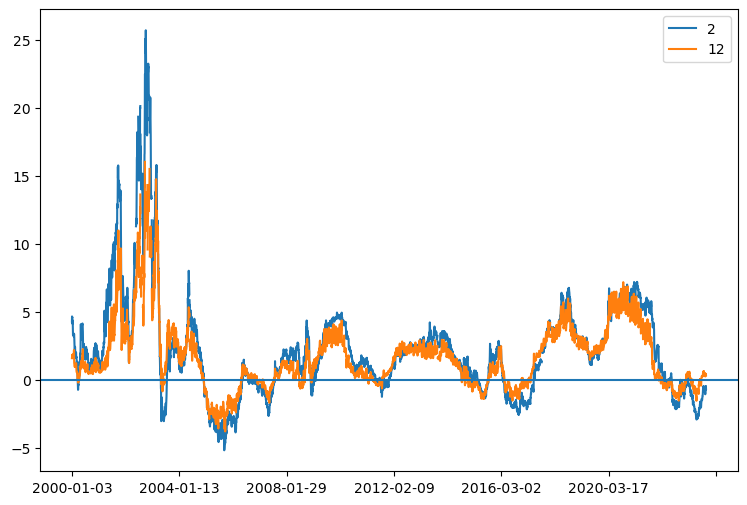

In [187]:
DI1_cores_df[['2', '12']].plot(figsize=(9, 6));
plt.axhline();

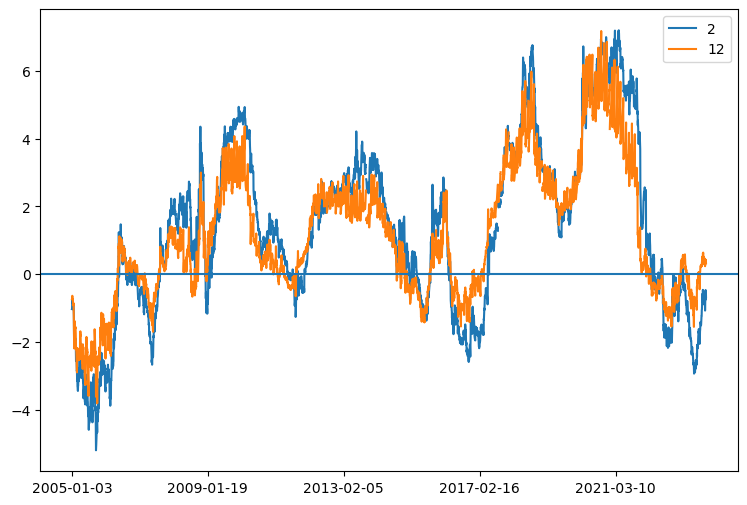

In [188]:
DI1_cores_df[['2', '12']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

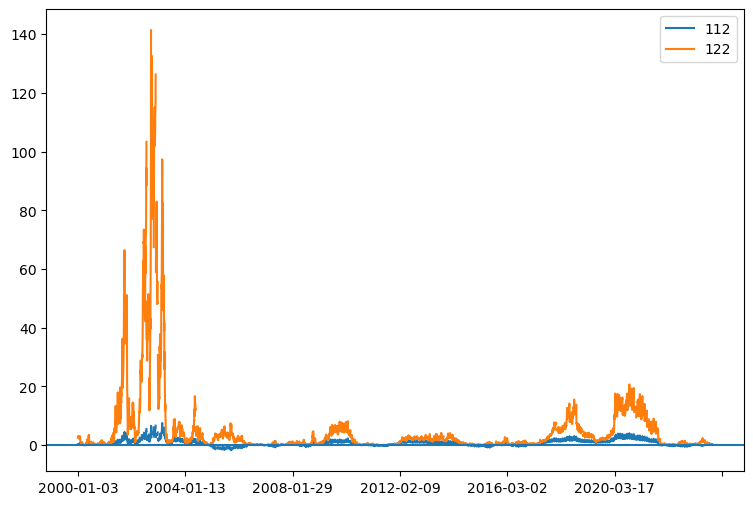

In [190]:
DI1_cores_df[['112', '122']].plot(figsize=(9, 6));
plt.axhline();

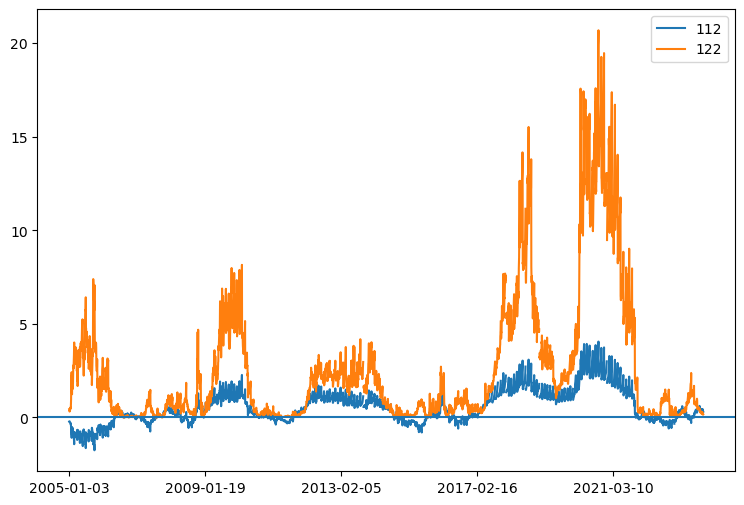

In [189]:
DI1_cores_df[['112', '122']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

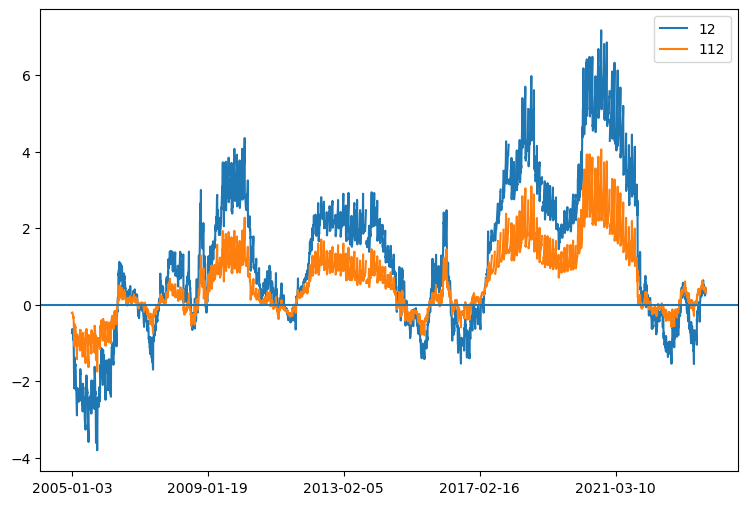

In [191]:
DI1_cores_df[['12', '112']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

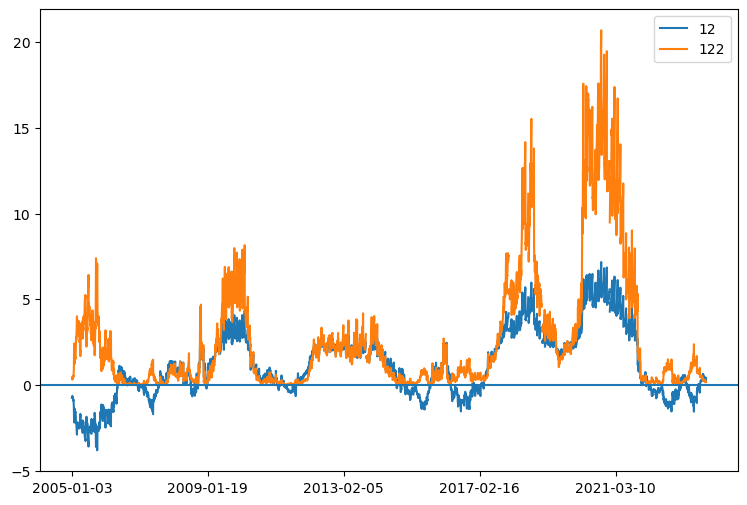

In [192]:
DI1_cores_df[['12', '122']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

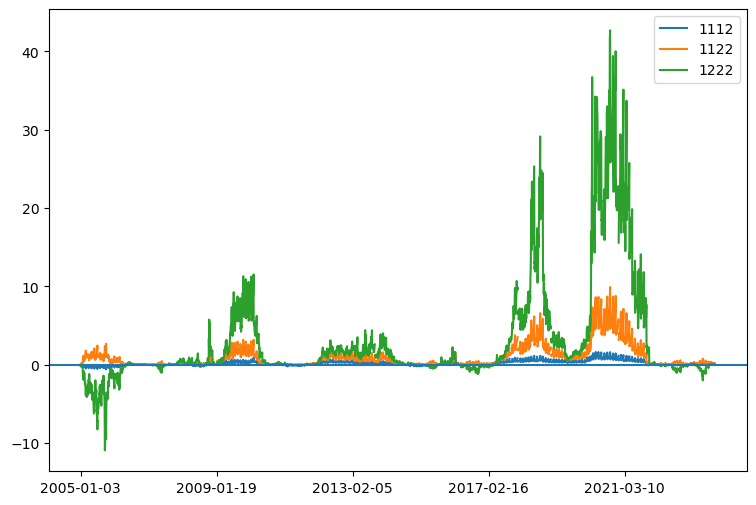

In [193]:
DI1_cores_df[['1112', '1122', '1222']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

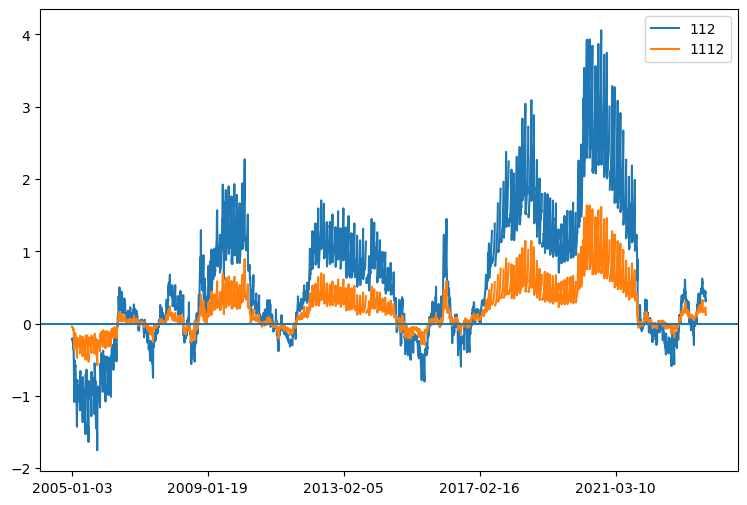

In [194]:
DI1_cores_df[['112', '1112']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

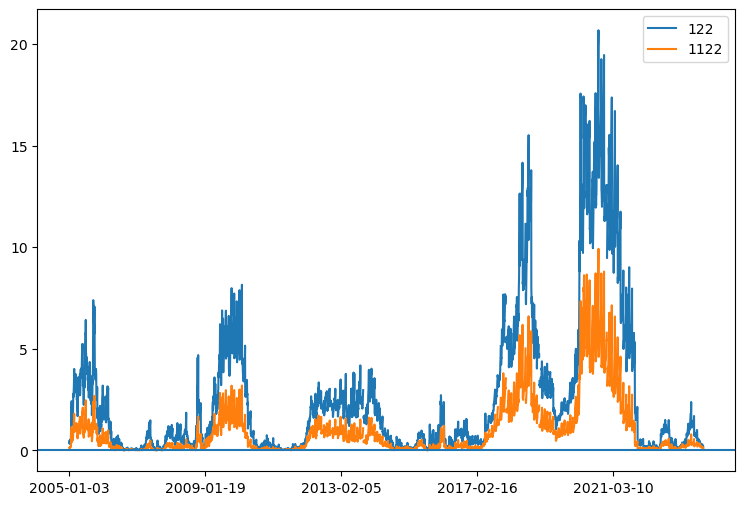

In [205]:
DI1_cores_df[['122', '1122']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();

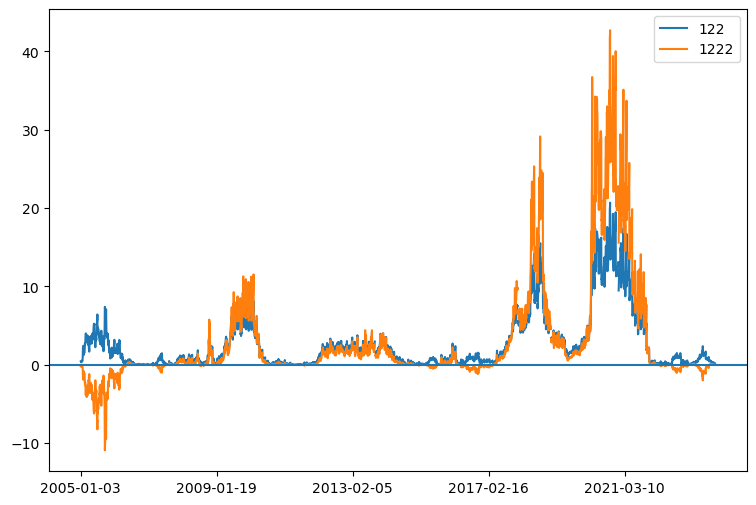

In [206]:
DI1_cores_df[['122', '1222']].loc['2005':].plot(figsize=(9, 6));
plt.axhline();